Part 2: Predictive Modeling & Strategy Formulation

In [6]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


In [7]:
data = pd.read_csv(
    "C:/Users/vja89/OneDrive - Students.iiit.ac.in - IIIT Hyderabad/Precog/data/cleaned_panel_data.csv",
    parse_dates=["Date"]
)


In [8]:
data.head()
data.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker'], dtype='str')

In [9]:
data = data.sort_values(["ticker", "Date"]).reset_index(drop=True)
# sorting each stock date by date


In [10]:
# 1-day log return
data["log_return_1d"] = (
    data.groupby("ticker")["Close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)


In [11]:
data["next_day_return"] = (
    data.groupby("ticker")["log_return_1d"]
    .shift(-1)
)


In [12]:
data[["ticker", "Date", "Close", "log_return_1d", "next_day_return"]].head(10)


,ticker,Date,Close,log_return_1d,next_day_return
0,anonymized_data\Asset_001,2016-01-25,28.580592,NaN,0.005515
1,anonymized_data\Asset_001,2016-01-26,28.738659,0.005515,-0.067965
2,anonymized_data\Asset_001,2016-01-27,26.850345,-0.067965,0.007146
3,anonymized_data\Asset_001,2016-01-28,27.042913,0.007146,0.033958
4,anonymized_data\Asset_001,2016-01-29,27.977016,0.033958,-0.009393
5,anonymized_data\Asset_001,2016-02-01,27.715465,-0.009393,-0.020429
6,anonymized_data\Asset_001,2016-02-02,27.155005,-0.020429,0.019599
7,anonymized_data\Asset_001,2016-02-03,27.692464,0.019599,0.008003
8,anonymized_data\Asset_001,2016-02-04,27.914984,0.008003,-0.027072
9,anonymized_data\Asset_001,2016-02-05,27.169420,-0.027072,0.010474


In [13]:
data["mom_5"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(5).sum())
)


In [14]:
data["mom_10"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(10).sum())
)


In [15]:
data[["ticker", "Date", "mom_5", "mom_10"]].head(15)


,ticker,Date,mom_5,mom_10
0,anonymized_data\Asset_001,2016-01-25,NaN,NaN
1,anonymized_data\Asset_001,2016-01-26,NaN,NaN
2,anonymized_data\Asset_001,2016-01-27,NaN,NaN
3,anonymized_data\Asset_001,2016-01-28,NaN,NaN
4,anonymized_data\Asset_001,2016-01-29,NaN,NaN
5,anonymized_data\Asset_001,2016-02-01,-0.030737,NaN
6,anonymized_data\Asset_001,2016-02-02,-0.056682,NaN
7,anonymized_data\Asset_001,2016-02-03,0.030882,NaN
8,anonymized_data\Asset_001,2016-02-04,0.031739,NaN
9,anonymized_data\Asset_001,2016-02-05,-0.029291,NaN


VOLATILITY FEATURES


In [16]:
data["vol_5"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(5).std())
)

# Higher vol_5 = more unstable stock.

In [17]:
data["vol_10"] = (
    data.groupby("ticker")["log_return_1d"]
    .transform(lambda x: x.rolling(10).std())
)


In [18]:
data[["ticker", "Date", "vol_5", "vol_10"]].head(15)


,ticker,Date,vol_5,vol_10
0,anonymized_data\Asset_001,2016-01-25,NaN,NaN
1,anonymized_data\Asset_001,2016-01-26,NaN,NaN
2,anonymized_data\Asset_001,2016-01-27,NaN,NaN
3,anonymized_data\Asset_001,2016-01-28,NaN,NaN
4,anonymized_data\Asset_001,2016-01-29,NaN,NaN
5,anonymized_data\Asset_001,2016-02-01,0.037925,NaN
6,anonymized_data\Asset_001,2016-02-02,0.037704,NaN
7,anonymized_data\Asset_001,2016-02-03,0.021813,NaN
8,anonymized_data\Asset_001,2016-02-04,0.021826,NaN
9,anonymized_data\Asset_001,2016-02-05,0.019462,NaN


In [19]:
data = data.dropna().reset_index(drop=True)


In [20]:
data[["mom_5", "mom_10", "vol_5", "vol_10", "next_day_return"]].describe()


,mom_5,mom_10,vol_5,vol_10,next_day_return
count,249999.000000,249999.000000,249999.000000,249999.000000,249999.000000
mean,0.003093,0.006172,0.015042,0.015785,0.000633
std,0.040856,0.056868,0.011645,0.010535,0.018856
min,-0.643795,-1.021977,0.000227,0.001237,-0.432578
25%,-0.016071,-0.021527,0.007968,0.009317,-0.007435
50%,0.004134,0.007864,0.012054,0.013120,0.000818
75%,0.023506,0.036091,0.018373,0.018989,0.009092
max,0.614004,0.527432,0.219445,0.169313,0.477590


📍 Where we are now

✔ NaNs understood and handled correctly
✔ Momentum features built
✔ Volatility features built
✔ Target defined
✔ Data clean

You are now READY for the Ridge model.


In [21]:
features = ["mom_5", "mom_10", "vol_5", "vol_10"]
target = "next_day_return"


In [22]:
LOOKBACK = 252   # number of past trading days used for training
ALPHA = 1.0      # Ridge regularization strength


In [23]:
data["predicted_return"] = np.nan


Explanation

We will fill this day by day

Only after the model is trained on the past

Ensures out-of-sample predictions

Rolling Ridge Regression

In [24]:
import numpy as np


In [25]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# unique trading days in sorted order
unique_dates = np.sort(data["Date"].unique())

for i in range(LOOKBACK, len(unique_dates)):
    # 1️⃣ define training and test period
    train_dates = unique_dates[i - LOOKBACK : i]
    test_date = unique_dates[i]
    
    train_data = data[data["Date"].isin(train_dates)]
    test_data = data[data["Date"] == test_date]
    
    # 2️⃣ separate features and target
    X_train = train_data[features]
    y_train = train_data[target]
    X_test = test_data[features]
    
    # 3️⃣ scale features (VERY important)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4️⃣ train Ridge model
    model = Ridge(alpha=ALPHA)
    model.fit(X_train_scaled, y_train)
    
    # 5️⃣ generate prediction for test day
    data.loc[test_data.index, "predicted_return"] = model.predict(X_test_scaled)


In [ ]:
data["predicted_return"].notna().mean()
# how much of the data actually got predictions i mean we have nans for initial lookback period

np.float64(0.8991995967983872)

In [27]:
data_ls = data.dropna(subset=["predicted_return"]).reset_index(drop=True)


In [28]:
data_ls["pred_rank"] = (
    data_ls.groupby("Date")["predicted_return"]
    .rank(ascending=False, method="first")
)


In [29]:
data_ls["n_assets"] = data_ls.groupby("Date")["ticker"].transform("count")


In [30]:
data_ls["is_long"] = data_ls["pred_rank"] <= 0.2 * data_ls["n_assets"]
data_ls["is_short"] = data_ls["pred_rank"] > 0.8 * data_ls["n_assets"]


In [31]:
data_ls[["is_long", "is_short"]].mean()


is_long     0.199996
is_short    0.200001
dtype: float64

In [32]:
long_returns = (
    data_ls[data_ls["is_long"]]
    .groupby("Date")["next_day_return"]
    .mean()
)

short_returns = (
    data_ls[data_ls["is_short"]]
    .groupby("Date")["next_day_return"]
    .mean()
)

portfolio_returns = long_returns - short_returns


In [33]:
cum_log_return = portfolio_returns.cumsum()
cum_return = np.exp(cum_log_return)


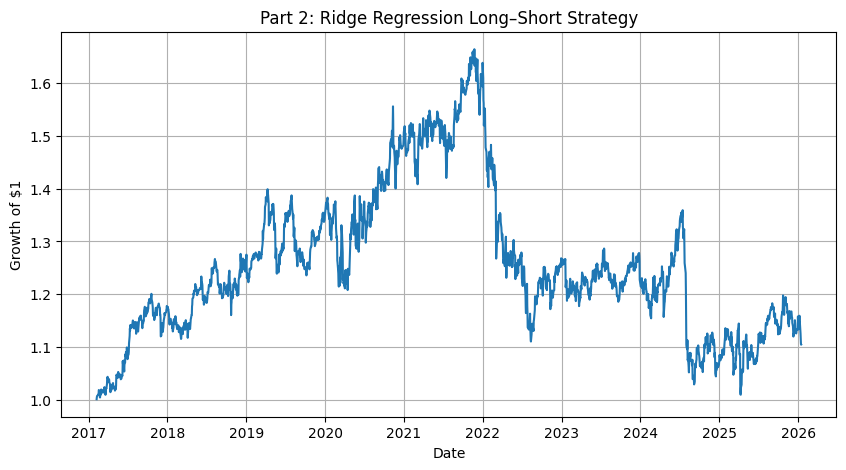

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(cum_return)
plt.title("Part 2: Ridge Regression Long–Short Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()


In [35]:
print("Final portfolio value:", cum_return.iloc[-1])
print("Mean daily return:", portfolio_returns.mean())
print("Daily volatility:", portfolio_returns.std())


Final portfolio value: 1.104573530251932
Mean daily return: 4.4243467526792376e-05
Daily volatility: 0.009955945175737392


In [36]:
data_ls["inv_vol"] = 1 / data_ls["vol_10"]


In [37]:
data_ls["long_weight"] = 0.0

long_mask = data_ls["is_long"]

data_ls.loc[long_mask, "long_weight"] = (
    data_ls.loc[long_mask, "inv_vol"] /
    data_ls.loc[long_mask].groupby("Date")["inv_vol"].transform("sum")
)


In [38]:
data_ls["short_weight"] = 0.0

short_mask = data_ls["is_short"]

data_ls.loc[short_mask, "short_weight"] = (
    - data_ls.loc[short_mask, "inv_vol"] /
    data_ls.loc[short_mask].groupby("Date")["inv_vol"].transform("sum")
)


In [39]:
data_ls["position_weight"] = data_ls["long_weight"] + data_ls["short_weight"]


In [40]:
portfolio_returns_vscaled = (
    data_ls.groupby("Date")
    .apply(lambda x: (x["position_weight"] * x["next_day_return"]).sum())
)


In [41]:
cum_log_return_vscaled = portfolio_returns_vscaled.cumsum()
cum_return_vscaled = np.exp(cum_log_return_vscaled)


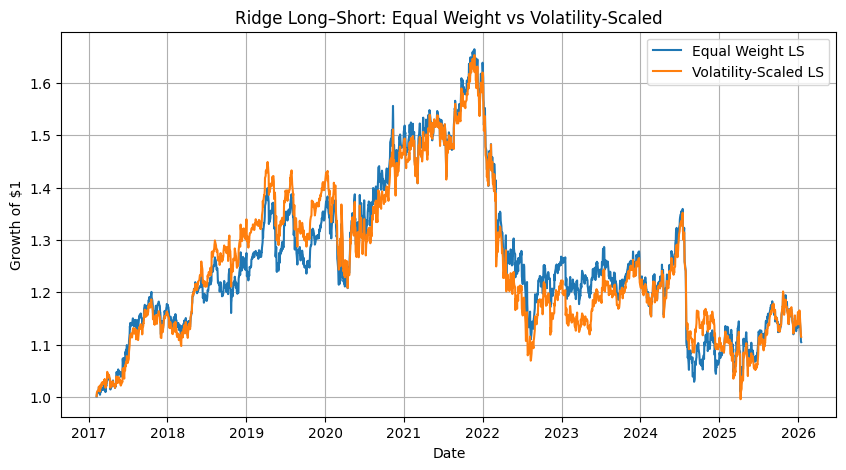

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(cum_return, label="Equal Weight LS")
plt.plot(cum_return_vscaled, label="Volatility-Scaled LS")
plt.legend()
plt.title("Ridge Long–Short: Equal Weight vs Volatility-Scaled")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()


In [43]:
market_returns = (
    data_ls.groupby("Date")["next_day_return"]
    .mean()
)


In [44]:
cum_market_log = market_returns.cumsum()
cum_market = np.exp(cum_market_log)


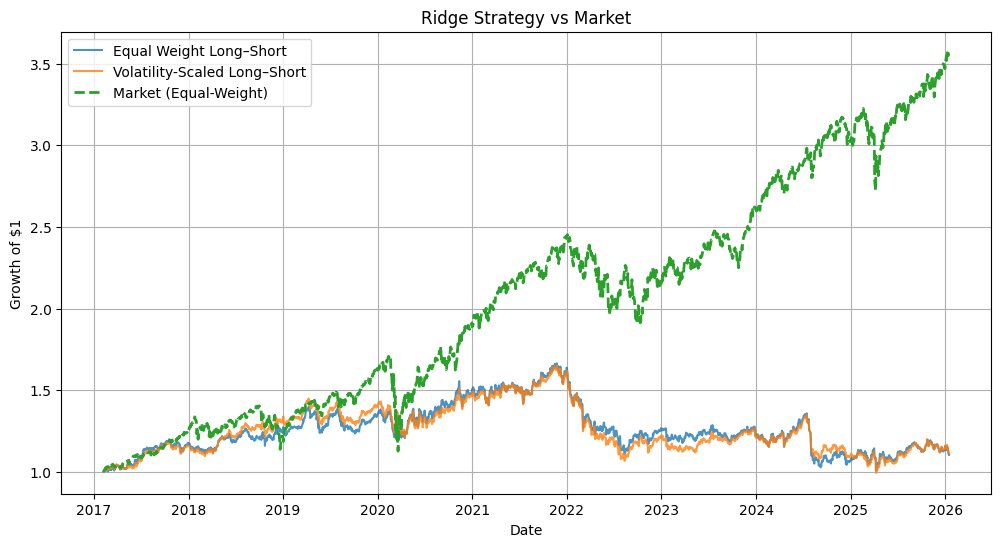

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(cum_return, label="Equal Weight Long–Short", alpha=0.8)
plt.plot(cum_return_vscaled, label="Volatility-Scaled Long–Short", alpha=0.8)
plt.plot(cum_market, label="Market (Equal-Weight)", linestyle="--", linewidth=2)

plt.title("Ridge Strategy vs Market")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


In [48]:
# ----- Part 1: Long-only Top 20% (Market-exposed) -----

data_p1 = data.copy()

# Rank by momentum (example: mom_10)
data_p1["rank"] = (
    data_p1.groupby("Date")["mom_10"]
    .rank(ascending=False, method="first")
)

data_p1["n_assets"] = (
    data_p1.groupby("Date")["ticker"].transform("count")
)

data_p1["is_long"] = data_p1["rank"] <= 0.2 * data_p1["n_assets"]

# Equal-weight long-only return
portfolio_returns_part1 = (
    data_p1[data_p1["is_long"]]
    .groupby("Date")["next_day_return"]
    .mean()
)

cum_return_part1 = np.exp(portfolio_returns_part1.cumsum())


NameError: name 'cum_return_gbdt' is not defined

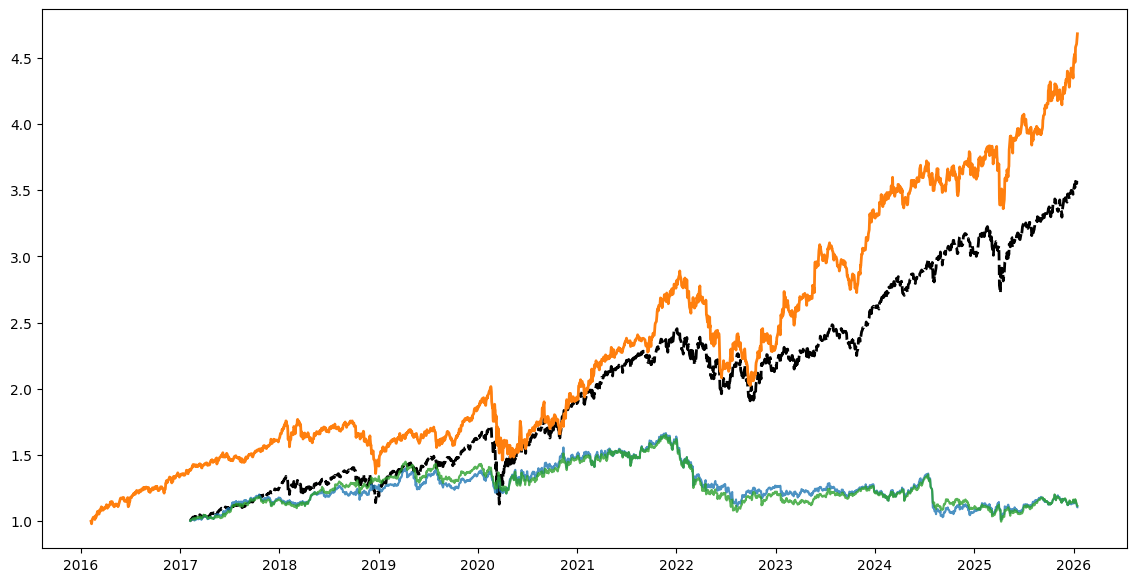

In [49]:
plt.figure(figsize=(14, 7))

# Market
plt.plot(
    cum_market,
    label="Market (Equal-Weight)",
    linestyle="--",
    linewidth=2,
    color="black"
)

# Part 1: Long-only Momentum
plt.plot(
    cum_return_part1,
    label="Part 1: Long-Only Top 20%",
    linewidth=2,
    color="tab:orange"
)

# Ridge Long–Short (Equal Weight)
plt.plot(
    cum_return,
    label="Ridge LS (Equal Weight)",
    alpha=0.8,
    color="tab:blue"
)

# Ridge Long–Short (Volatility Scaled)
plt.plot(
    cum_return_vscaled,
    label="Ridge LS (Volatility-Scaled)",
    alpha=0.8,
    color="tab:green"
)

# GBDT Long–Short (Volatility Scaled)
plt.plot(
    cum_return_gbdt,
    label="GBDT LS (Volatility-Scaled)",
    linewidth=2.5,
    color="tab:red"
)

plt.title("Full Strategy Comparison: Market vs Long-Only vs Long–Short Models")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)

plt.show()
